In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
df=pd.read_csv('Admission_predict.csv')

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [5]:
df.isnull().sum()*100 
# no null value

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [6]:
df.duplicated().sum()
# no duplicate value

np.int64(0)

In [7]:
df.drop(columns=['Serial No.'],inplace=True)
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [8]:
# divide the data into input and output
X=df.drop(columns=['Chance of Admit '])
y=df['Chance of Admit ']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# split the data into training and testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=233)
X_train.shape

(320, 7)

In [11]:
# now scaling -min max(as we know the max and min value here)

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
X_train_scaled

array([[0.14893617, 0.46428571, 0.        , ..., 0.25      , 0.22058824,
        0.        ],
       [0.10638298, 0.        , 0.        , ..., 0.25      , 0.25      ,
        0.        ],
       [0.72340426, 0.75      , 0.75      , ..., 0.5       , 0.54779412,
        1.        ],
       ...,
       [0.21276596, 0.46428571, 1.        , ..., 0.875     , 0.53308824,
        0.        ],
       [0.17021277, 0.21428571, 0.        , ..., 0.5       , 0.30514706,
        1.        ],
       [0.5106383 , 0.28571429, 0.25      , ..., 0.375     , 0.50367647,
        0.        ]], shape=(320, 7))

In [13]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model=Sequential()

model.add(Dense(20,activation='relu',input_dim=7))
model.add(Dense(15,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='linear'))

C:\Users\syedm\anaconda3\envs\eda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='mean_squared_error',optimizer='Adam',metrics=['r2_score'])

In [17]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1616 - r2_score: -6.7043 - val_loss: 0.1006 - val_r2_score: -4.6200
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0676 - r2_score: -2.2227 - val_loss: 0.0356 - val_r2_score: -0.9862
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0280 - r2_score: -0.3340 - val_loss: 0.0229 - val_r2_score: -0.2766
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 - r2_score: -0.2103 - val_loss: 0.0238 - val_r2_score: -0.3310
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0214 - r2_score: -0.0212 - val_loss: 0.0167 - val_r2_score: 0.0660
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0155 - r2_score: 0.2633 - val_loss: 0.0118 - val_r2_score: 0.3411
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - r2_score: 0.4058 - val_loss: 0.0096 - val_r2_score: 0.4637
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107 - r2_score: 0.4901 - val_loss: 0.0081 - val_r2_

In [18]:
y_pred=model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [19]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8031825186576929

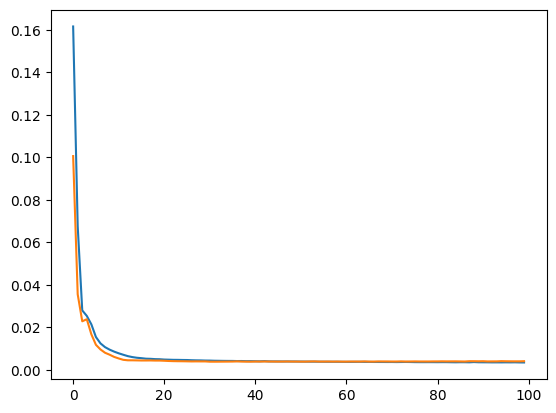

In [20]:
# plot

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

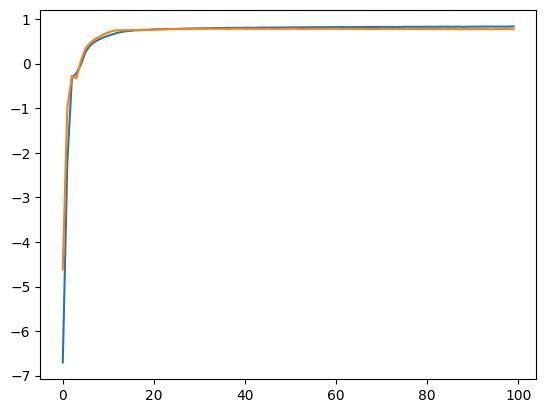

In [21]:
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])